### The Problem: Customer Segmentation for a Subscription Streaming Service


You're a data scientist at a streaming platform. The marketing team wants to move from generic campaigns to targeted ones, and they've asked you to build customer segments based on behavior and demographics. They also want recommendations for which segments to prioritize for retention vs. growth campaigns.
You'll work with four tables that need to be cleaned and joined. The dataset has the kind of mess you've now seen multiple times — bad column names, mixed formats, missing values, dupes — plus a few new wrinkles (categorical encoding, outliers, leaky features).

In [1]:
import pandas as pd
import re
import datetime as dt
import numpy as np
import matplotlib.pyplot as plt
import math

#### Phase 1 — Feature engineering (the hard part of any ML project)

##### 1. Data hygiene. Clean column names, parse dates, handle missing/junk values, dedupe. Document each decision. Sanity-check by joining the tables and looking for orphans (sessions with no user, etc.).

In [5]:
def clean_headers(df):
    df.columns = df.columns \
        .map(lambda x: x.lower().strip()) \
        .str.replace(' ', '_') \
        .str.replace(r'[^a-zA-Z_%]', '', regex=True)
    return df

def parse_mixed_timestamps(d):
    
    datetime_regex = [ \
        (r"^\d{4}-\d{2}-\d{2}\s\d{2}:\d{2}:\d{2}[+-]\d{2}:\d{2}$", "%Y-%m-%d %H:%M:%S%z"),
        (r"^\d{4}-\d{2}-\d{2}\s\d{2}:\d{2}:\d{2}$", "%Y-%m-%d %H:%M:%S"),
        (r"^\d{2}-\d{2}-\d{4}\s\d{2}:\d{2}:\d{2}$", "%d-%m-%Y %H:%M:%S"),
        (r"^\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}$",  "%Y-%m-%dT%H:%M:%S"),
        (r"^\d{2}/\d{2}/\d{4} \d{2}:\d{2}:\d{2}$",  "%m/%d/%Y %H:%M:%S"),
        
        (r"^\d{2}/\d{2}/\d{4} \d{2}:\d{2}$",  "%m/%d/%Y %H:%M"),
        (r"^[A-Z][a-z]{2}\s\d{1,2},\s\d{4} \d{2}:\d{2}$", "%b %d, %Y %H:%M"),
        
        (r"^\d{4}-\d{2}-\d{2}$", "%Y-%m-%d"),
        (r"^\d{4}-\d{2}-\d{2}$", "%Y-%m-%d"),
        (r"^\d{2}-\d{2}-\d{4}$", "%d-%m-%Y"),
        (r"^\d{4}-\d{2}-\d{2}$",  "%Y-%m-%d"),
        (r"^\d{2}/\d{2}/\d{4}$",  "%m/%d/%Y"),
        (r"^[A-Z][a-z]{2}\s\d{1,2},\s\d{4}$", "%b %d, %Y")
        ]

    
    if str(d)=='nan':
        return None

    try:
        for fmt in datetime_regex:
            match = re.search(fmt[0], d)
            if match != None:    
                return dt.datetime.strptime(d, fmt[1])
    except ValueError:
        return d

def mixed_to_bool(s):
    return s in ['1','TRUE','true','yes','1']


# Read Files
users = pd \
    .read_csv('data/users.csv') \
    .pipe(clean_headers)
content = pd.read_csv('data/content.csv').pipe(clean_headers)
subscriptions = pd.read_csv('data/subscriptions.csv').pipe(clean_headers)
viewing_sessions = pd.concat([pd.read_csv(f) for f in ['data/viewing_sessions_1.csv','data/viewing_sessions_2.csv']]).pipe(clean_headers)


# cleans
print("Cleaning Users ...")
users.signup_date = users.apply(lambda l: parse_mixed_timestamps(l.signup_date), axis=1)
users.loc[users.age < 10] = users.loc[users.age > 100] = None
users['age'] = users['age'].astype('Int64')
users = users.set_index('user_id').dropna()

print("...done")
print("Cleaning Subscriptions ...")
# 4 null values in price, replace with mean value of their plan


subscriptions.start = subscriptions.apply(lambda l: parse_mixed_timestamps(l.start), axis=1)
subscriptions.end = subscriptions.apply(lambda l: parse_mixed_timestamps(l.end), axis=1)
subscriptions.price_mo = subscriptions.price_mo.str.replace('$','').astype('float')
# replaces null values in price with mean of their plan
subscriptions.price_mo = subscriptions.price_mo.fillna(subscriptions.groupby('plan')['price_mo'].transform('mean'))
subscriptions.canceled = subscriptions.apply(lambda l: mixed_to_bool(l.canceled), axis=1)
subscriptions = subscriptions[subscriptions['user_id'].isin(users.index)]
subscriptions.set_index('sub_id', inplace=True)
print("...done")

print("Cleaning Content ...")
content.set_index('content_id', inplace=True)
print("... done")

print("Cleaning Viewing Sessions ...")
viewing_sessions.start_time = viewing_sessions.apply(lambda l: parse_mixed_timestamps(l.start_time), axis=1)
viewing_sessions = viewing_sessions.set_index('session_id').drop_duplicates().rename(columns={'completion_%':'completion_pct'})
# Removes sessions with no matching user_id or content_id
viewing_sessions = viewing_sessions[viewing_sessions['content_id'].isin(content.index)]
viewing_sessions = viewing_sessions[viewing_sessions['user_id'].isin(users.index)]

print('...done')

Cleaning Users ...
...done
Cleaning Subscriptions ...
...done
Cleaning Content ...
... done
Cleaning Viewing Sessions ...
...done


2. Customer feature matrix. For each user, build a feature row containing:

Demographics: age (handle outliers/impossible values), gender, country, tenure in days
Subscription behavior: current tier, total months subscribed, number of plan changes, ever-canceled flag
Viewing behavior: total watch hours, sessions per week (averaged over tenure), average completion %, weekend-vs-weekday ratio, device diversity (number of distinct devices)
Content preferences: top genre, genre diversity (Shannon entropy or just count of distinct genres), share of watch time on series vs. movies
Recency: days since last session

This is the meat of the problem. The output should be one row per user with ~15–20 columns, all numeric or properly encoded.

In [8]:
features = users.copy()

# Add calculated fields

features['total_months_subscribed'] = pd.merge(pd.to_datetime(users.signup_date).dt.to_period('M'), 
         pd.to_datetime(subscriptions.groupby('user_id').end.max()).dt.to_period('M'), 
         on='user_id').fillna(pd.to_datetime('today').to_period('M')).apply(lambda l: l.end - l.signup_date, axis=1).apply(lambda x: x.n)
features[['subscription_changes','ever_canceled']] = subscriptions \
    .reset_index() \
    .groupby('user_id') \
    .agg(subscription_changes=('sub_id','count'),
         ever_canceled=('canceled','sum')).assign(ever_canceled = lambda l: l.ever_canceled == 1)



features[['average_completion_rate','total_watch_hours', 'device_diversity', 'sessions_per_week']] = \
    viewing_sessions \
        .reset_index() \
        .groupby('user_id') \
        .agg(average_completion_rate=('completion_pct','mean'),
             total_watch_hours=('watch_duration_s',lambda x: round(sum(x) / 3600, 2)),
             device_diversity=('device',lambda x: x.nunique() / 5),
             total_weeks=('start_time',lambda x: x.dt.to_period('W').nunique()),
             total_sessions=('session_id','count')) \
        .assign(sessions_per_week = lambda x: x.total_sessions / x.total_weeks) \
        .drop(columns=['total_weeks','total_sessions'])

features['sessions_per_week'] = viewing_sessions. \
    assign(week=lambda x: x.start_time.dt.to_period('W')). \
    reset_index(). \
    groupby('user_id'). \
    agg(total_weeks=('week','nunique'),
        total_sessions=('session_id','count')). \
    apply(lambda l: round(l.total_sessions / l.total_weeks, 4), axis=1)

features['weekend_ratio'] = viewing_sessions. \
    assign(is_weekend=lambda l: l.start_time.dt.strftime('%A').isin(['Saturday','Sunday'])). \
    groupby('user_id'). \
    agg({'is_weekend':'sum','watch_duration_s':'count'}). \
    apply(lambda l: l.is_weekend / l.watch_duration_s, axis=1)


# Shannon Entropy represents diversity in populations of unequal sizes.
# Larger populations represent a greater share of the overall ecosystem
genre_num_titles = content.groupby('genre').title.count().sort_values()
total_titles = genre_num_titles.sum()
shannon_entropy = -sum([pop/genre_num_titles.sum()*math.log(pop/genre_num_titles.sum()) for pop in genre_num_titles])

features[['top_genre','genre_diversity_shannon','days_since_last_session']] = \
    pd.merge(viewing_sessions,content[['genre','type']],on='content_id') \
        .groupby('user_id') \
        .agg(top_genre=('genre',lambda l: l.value_counts().idxmax()),
             genre_diversity_shannon=('genre', \
                                      lambda l: -sum([genre/total_titles.sum()*math.log(genre/total_titles.sum()) \
                                                      for genre in genre_num_titles[l.unique()]]) / shannon_entropy ),
             days_since_last_session=('start_time',lambda l: (pd.to_datetime('today') -l).min()/ np.timedelta64(1, 'D'))
            )

features[['movie_share','series_share']] = \
    pd.merge(viewing_sessions,content[['genre','type']],on='content_id') \
        .groupby(['user_id','type']) \
        .watch_duration_s.sum().unstack() \
        .apply(lambda l: l/l.sum(), axis=1) \
        .rename(columns={'movie':'movie_share','series':'series_share'}) \
        .drop(columns='documentary')

# Encodes each categorical column with unique values
for col in features.select_dtypes('str').columns:
    features[col] = pd.factorize(features[col])[0]

# Encodes Bool Columns
bool_cols = features.select_dtypes('bool').columns
features[bool_cols] = features[bool_cols].astype('int')
features

# Converts datetimes to integer
features.signup_date = features.signup_date.dt.strftime('%Y%m%d').astype('int')

features.head()

,signup_date,age,gender,country,signup_channel,tier_at_signup,total_months_subscribed,subscription_changes,ever_canceled,average_completion_rate,total_watch_hours,device_diversity,sessions_per_week,weekend_ratio,top_genre,genre_diversity_shannon,days_since_last_session,movie_share,series_share
user_id,,,,,,,,,,,,,,,,,,,
U00001,20230128,58,0,0,0,0,15,3,0,89.578814,244.30,0.2,2.3838,0.567797,0,1.000000,414.769201,0.276421,0.083577
U00002,20220331,36,0,1,0,1,8,3,0,70.197817,219.48,0.6,1.8770,0.620087,1,0.952726,417.594201,0.813989,0.076708
U00003,20240721,59,0,1,1,1,22,1,0,87.585227,85.39,0.2,2.6667,0.568182,0,0.919552,414.807395,0.215778,0.083807
U00004,20230513,48,1,2,2,1,36,1,0,88.836585,244.06,0.2,2.6452,0.548780,0,1.000000,414.892812,0.218399,0.086365
U00005,20230514,37,0,0,3,1,17,2,1,68.053425,66.20,0.4,1.7381,0.616438,1,0.930951,580.870590,0.802058,0.088542


#### Phase 2 — Segmentation
3. Exploratory analysis. Distributions of key features. Correlations. Are there obvious clusters visible in scatter plots of (watch_hours, recency) or (tenure, completion_pct)? PCA to 2D — does it show structure?


total_watch_hours  sessions_per_week    0.734231
device_diversity   sessions_per_week    0.721002
sessions_per_week  series_share         0.793970
dtype: float64


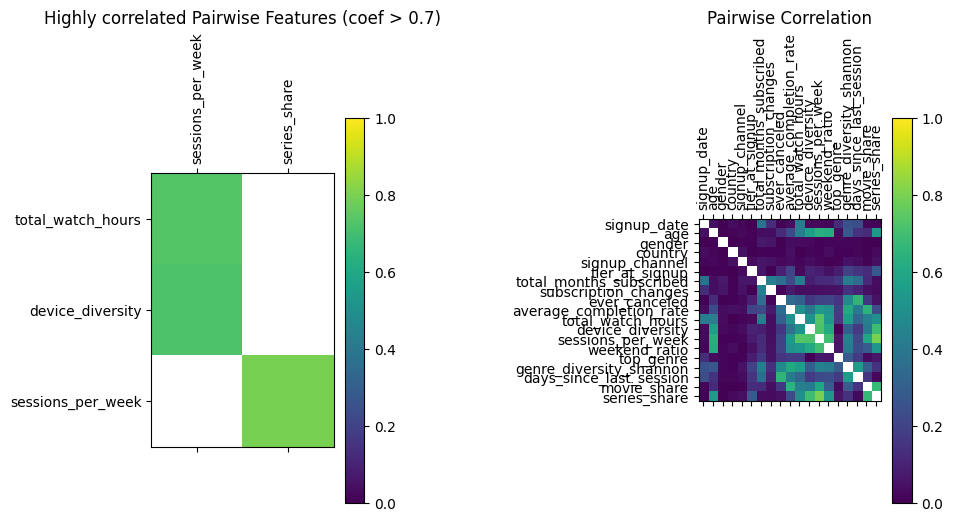

Highly correlated fields include: ['total_watch_hours', 'device_diversity', 'sessions_per_week', 'series_share']


In [9]:
corr_matrix = features.corr()

# absolute the matrix to also examine high negative correlations
corr_pairs = corr_matrix.abs().unstack()

# remove self-correlation
corr_pairs = corr_pairs[corr_pairs.index.get_level_values(0) != corr_pairs.index.get_level_values(1)]

threshold = 0.7
high_corr = corr_pairs[corr_pairs > threshold].drop_duplicates()

high_corr = high_corr.unstack()

print(high_corr.stack().dropna())



fig = plt.figure(figsize=(10, 5))
ax1 = fig.add_subplot(131)
cax = ax1.matshow(high_corr, vmax = 1, vmin=0)
fig.colorbar(cax)

ax1.set_xticks(range(len(high_corr.columns)))
ax1.set_xticklabels(high_corr.columns, rotation='vertical')
ax1.set_yticks(range(len(high_corr.index)))
ax1.set_yticklabels(high_corr.index)

ax1.set_title(f"Highly correlated Pairwise Features (coef > {threshold})")


corr_pairs = corr_pairs.unstack()


ax2 = fig.add_subplot(133)
cax = ax2.matshow(corr_pairs, vmax = 1, vmin=0)
fig.colorbar(cax)

ax2.set_xticks(range(len(corr_pairs.columns)))
ax2.set_xticklabels(corr_pairs.columns, rotation='vertical')
ax2.set_yticks(range(len(corr_pairs.index)))
ax2.set_yticklabels(corr_pairs.index)

ax2.set_title(f"Pairwise Correlation")
plt.show()

print(f'Highly correlated fields include: {list(high_corr.index.append( high_corr.columns ).unique())}')

In [10]:
pd.concat([
    
    corr_pairs[corr_pairs > threshold].unstack().dropna(), 
    corr_pairs[corr_pairs > threshold].unstack().dropna().swaplevel(0,1)
    ])

total_watch_hours  sessions_per_week    0.734231
device_diversity   sessions_per_week    0.721002
sessions_per_week  total_watch_hours    0.734231
                   device_diversity     0.721002
                   series_share         0.793970
series_share       sessions_per_week    0.793970
sessions_per_week  total_watch_hours    0.734231
                   device_diversity     0.721002
total_watch_hours  sessions_per_week    0.734231
device_diversity   sessions_per_week    0.721002
series_share       sessions_per_week    0.793970
sessions_per_week  series_share         0.793970
dtype: float64